# 05) Variance and Standard Deviation

Each visualization is intentionally in a separate code cell so you can run and inspect them independently.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Canonical data
config_a = np.array([
    4.1, 4.3, 4.2, 4.0, 4.4, 4.2, 4.1, 4.3, 4.2, 4.0,
    4.3, 4.2, 4.4, 4.1, 4.2, 4.3, 4.0, 4.2, 4.3, 4.1,
    4.2, 4.4, 4.1, 4.3, 4.2, 4.0, 4.3, 4.2, 4.1, 4.4
])

config_b = np.array([
    4.8, 2.9, 4.7, 3.1, 4.8, 2.8, 4.9, 3.0, 4.7, 2.9,
    4.8, 3.2, 4.6, 2.7, 4.9, 3.0, 4.8, 2.8, 4.7, 3.1,
    4.8, 2.9, 4.7, 3.0, 4.9, 2.8, 4.8, 3.1, 4.7, 2.9
])

days = np.arange(1, 31)
mu = 4.2

## Visualisation 1 - 30 days of scores

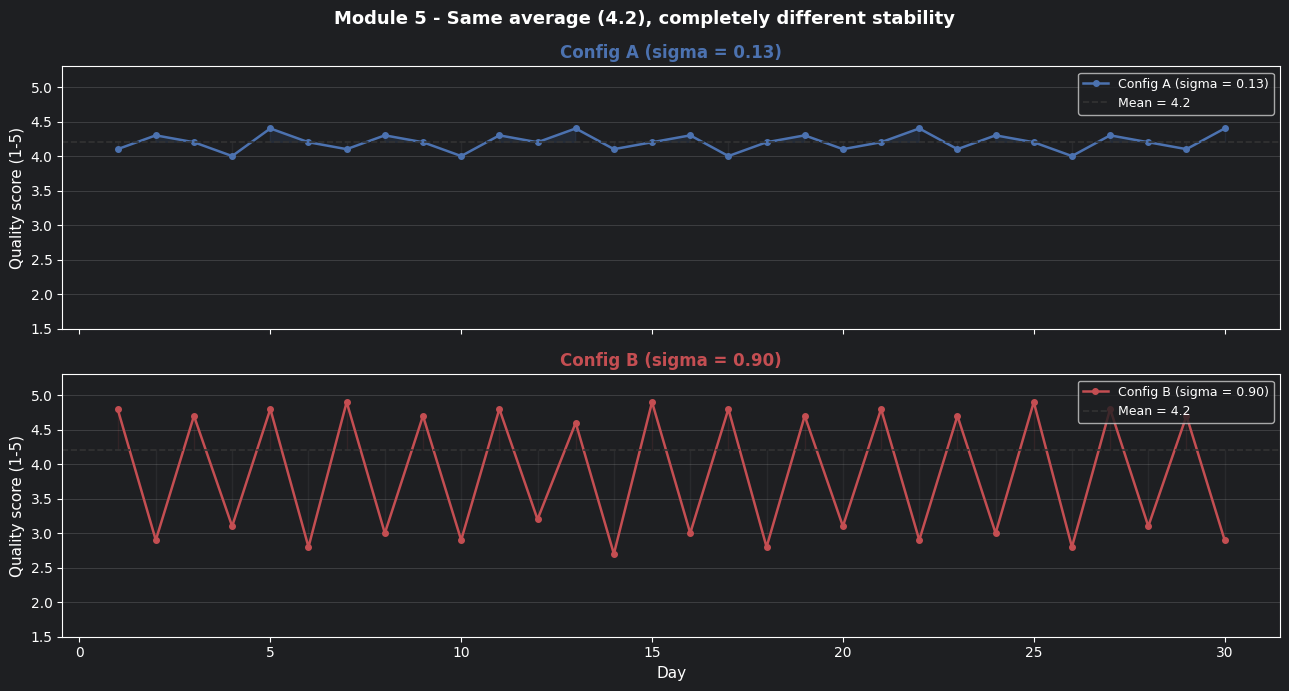

Config A:  mu=4.203  Var=0.015  sigma=0.122
Config B:  mu=3.860  Var=0.847  sigma=0.920


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, sharey=True)

for ax, scores, label, color in zip(
    axes,
    [config_a, config_b],
    ["Config A (sigma = 0.13)", "Config B (sigma = 0.90)"],
    ["#4C72B0", "#C44E52"]
):
    ax.plot(days, scores, color=color, linewidth=1.8, marker="o",
            markersize=4, label=label)
    ax.axhline(mu, color="#333333", linestyle="--", linewidth=1.2,
               label=f"Mean = {mu}")
    ax.fill_between(days, scores, mu, where=(scores >= mu), alpha=0.12, color=color)
    ax.fill_between(days, scores, mu, where=(scores < mu), alpha=0.12, color="grey")
    ax.set_ylim(1.5, 5.3)
    ax.set_ylabel("Quality score (1-5)", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold", color=color)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(axis="y", alpha=0.3)

axes[1].set_xlabel("Day", fontsize=11)
fig.suptitle("Module 5 - Same average (4.2), completely different stability",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("m5_fig1_30day_scores.png", dpi=150)
plt.show()

for name, scores in [("Config A", config_a), ("Config B", config_b)]:
    mu_ = np.mean(scores)
    var_ = np.var(scores)
    sig_ = np.std(scores)
    print(f"{name}:  mu={mu_:.3f}  Var={var_:.3f}  sigma={sig_:.3f}")

## Visualisation 2 - Squared deviations

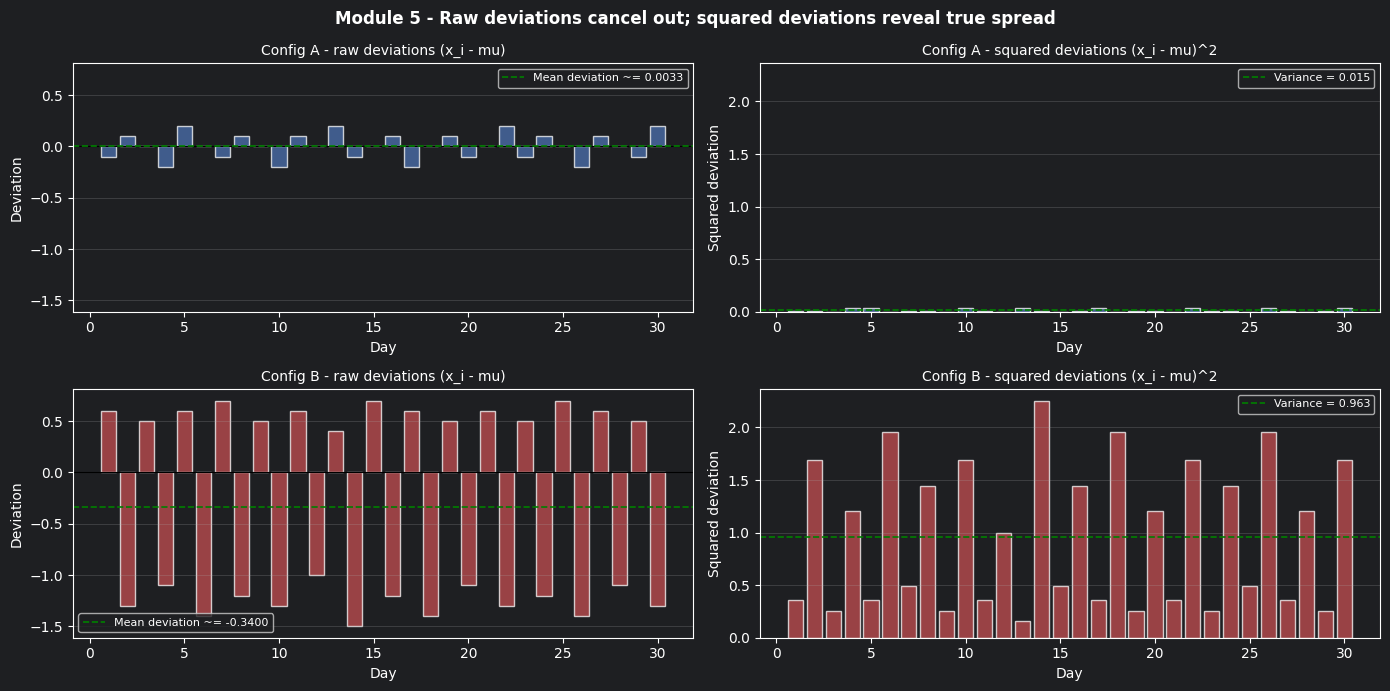

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey="col")

for row, (scores, label, color) in enumerate(zip(
    [config_a, config_b],
    ["Config A", "Config B"],
    ["#4C72B0", "#C44E52"]
)):
    deviations = scores - mu
    squared_devs = deviations ** 2

    ax = axes[row][0]
    ax.bar(days, deviations, color=color, alpha=0.75, edgecolor="white")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(np.mean(deviations), color="green", linestyle="--",
               linewidth=1.2, label=f"Mean deviation ~= {np.mean(deviations):.4f}")
    ax.set_title(f"{label} - raw deviations (x_i - mu)", fontsize=10)
    ax.set_ylabel("Deviation", fontsize=10)
    ax.set_xlabel("Day", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    ax = axes[row][1]
    ax.bar(days, squared_devs, color=color, alpha=0.75, edgecolor="white")
    ax.axhline(np.mean(squared_devs), color="green", linestyle="--",
               linewidth=1.2, label=f"Variance = {np.mean(squared_devs):.3f}")
    ax.set_title(f"{label} - squared deviations (x_i - mu)^2", fontsize=10)
    ax.set_ylabel("Squared deviation", fontsize=10)
    ax.set_xlabel("Day", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Module 5 - Raw deviations cancel out; squared deviations reveal true spread",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("m5_fig2_squared_deviations.png", dpi=150)
plt.show()

## Visualisation 3 - Histogram comparison

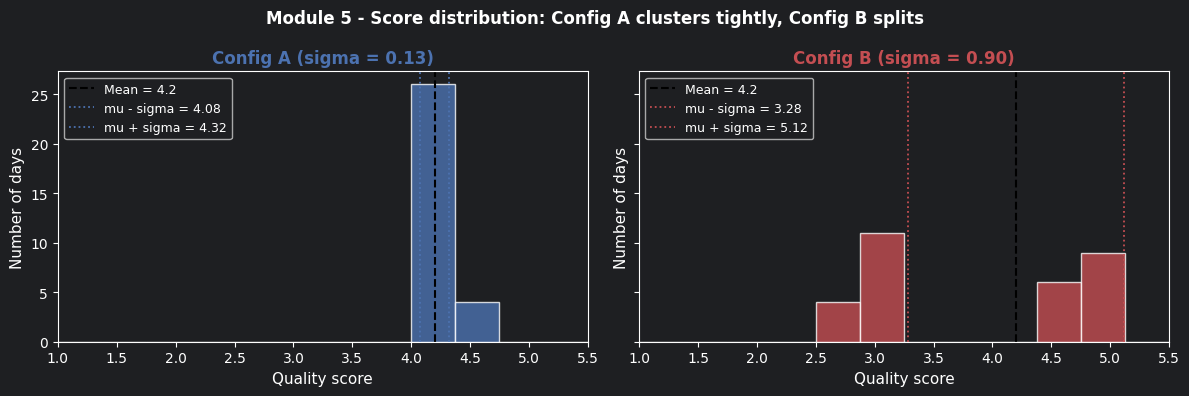

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, scores, label, color, sig in zip(
    axes,
    [config_a, config_b],
    ["Config A (sigma = 0.13)", "Config B (sigma = 0.90)"],
    ["#4C72B0", "#C44E52"],
    [np.std(config_a), np.std(config_b)]
):
    ax.hist(scores, bins=12, color=color, alpha=0.80, edgecolor="white", range=(1, 5.5))
    ax.axvline(mu, color="black", linestyle="--", linewidth=1.5, label=f"Mean = {mu}")
    ax.axvline(mu - sig, color=color, linestyle=":", linewidth=1.3,
               label=f"mu - sigma = {mu - sig:.2f}")
    ax.axvline(mu + sig, color=color, linestyle=":", linewidth=1.3,
               label=f"mu + sigma = {mu + sig:.2f}")
    ax.set_xlim(1, 5.5)
    ax.set_xlabel("Quality score", fontsize=11)
    ax.set_ylabel("Number of days", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold", color=color)
    ax.legend(fontsize=9)

fig.suptitle("Module 5 - Score distribution: Config A clusters tightly, Config B splits",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("m5_fig3_histograms.png", dpi=150)
plt.show()

## Visualisation 4 - 68-95-99.7 bands

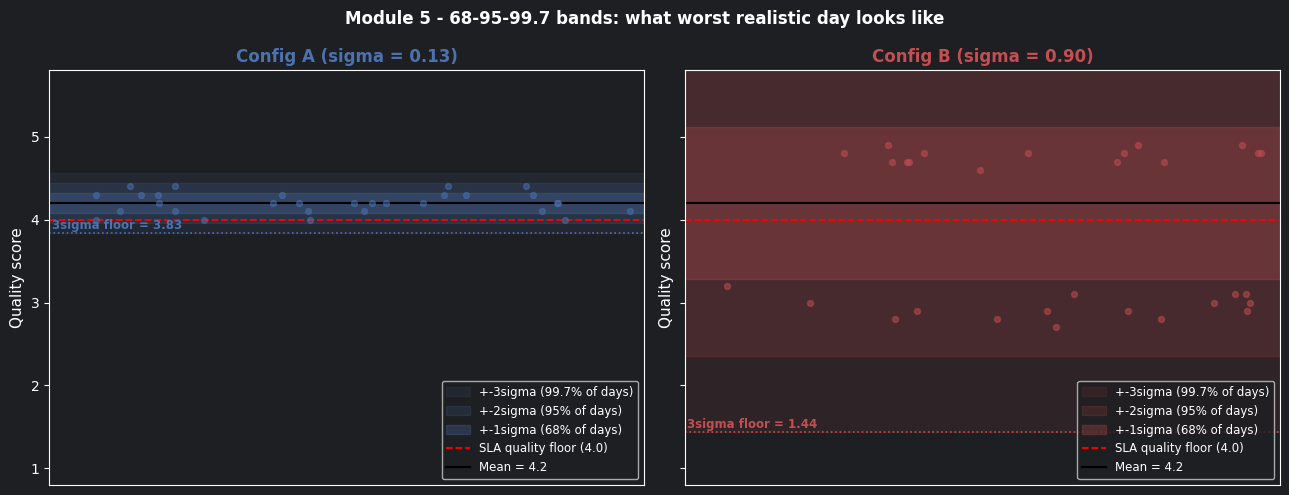

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, scores, label, color, sig in zip(
    axes,
    [config_a, config_b],
    ["Config A (sigma = 0.13)", "Config B (sigma = 0.90)"],
    ["#4C72B0", "#C44E52"],
    [np.std(config_a), np.std(config_b)]
):
    for n_sig, alpha, band_label in [
        (3, 0.10, "+-3sigma (99.7% of days)"),
        (2, 0.17, "+-2sigma (95% of days)"),
        (1, 0.28, "+-1sigma (68% of days)"),
    ]:
        ax.axhspan(mu - n_sig * sig, mu + n_sig * sig,
                   alpha=alpha, color=color, label=band_label)

    ax.axhline(4.0, color="red", linestyle="--", linewidth=1.3,
               label="SLA quality floor (4.0)")
    ax.axhline(mu, color="black", linestyle="-", linewidth=1.5,
               label=f"Mean = {mu}")

    floor = mu - 3 * sig
    ax.axhline(floor, color=color, linestyle=":", linewidth=1.2)
    ax.text(0.52, floor + 0.05, f"3sigma floor = {floor:.2f}",
            fontsize=8.5, color=color, fontweight="bold")

    ax.scatter(np.random.uniform(0.6, 5.4, len(scores)), scores,
               color=color, alpha=0.5, s=18, zorder=4)

    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(0.8, 5.8)
    ax.set_xticks([])
    ax.set_ylabel("Quality score", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold", color=color)
    ax.legend(fontsize=8.5, loc="lower right")

fig.suptitle("Module 5 - 68-95-99.7 bands: what worst realistic day looks like",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("m5_fig4_sigma_bands.png", dpi=150)
plt.show()

## Visualisation 5 - Go/no-go gate (mean vs standard deviation)

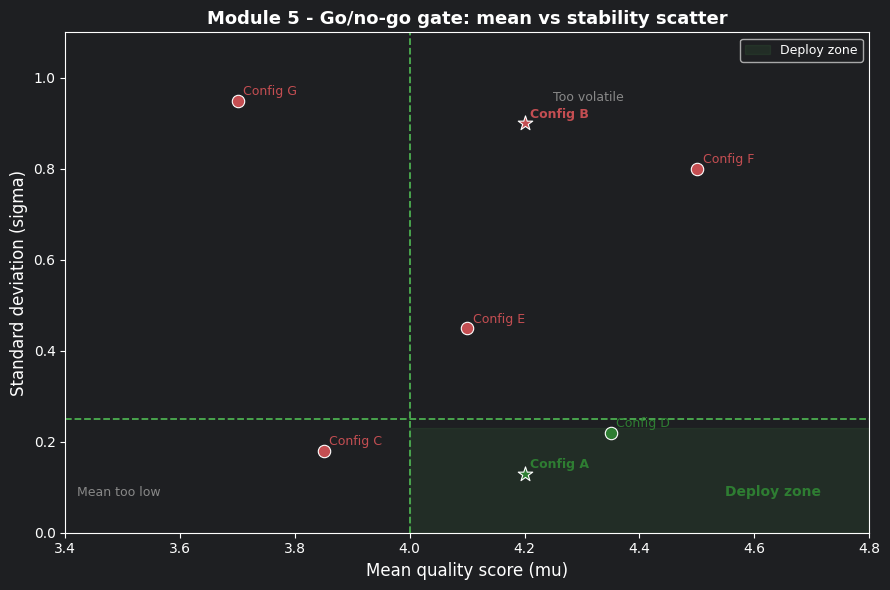

In [8]:
configs = [
    (4.20, 0.13, "Config A", True),
    (4.20, 0.90, "Config B", True),
    (3.85, 0.18, "Config C", False),
    (4.35, 0.22, "Config D", False),
    (4.10, 0.45, "Config E", False),
    (4.50, 0.80, "Config F", False),
    (3.70, 0.95, "Config G", False),
]

mu_floor = 4.0
sig_ceil = 0.25

fig, ax = plt.subplots(figsize=(9, 6))

ax.axvspan(mu_floor, 5.0, ymin=0, ymax=sig_ceil / 1.2,
           alpha=0.10, color="#4CAF50", label="Deploy zone")
ax.axhline(sig_ceil, color="#4CAF50", linestyle="--", linewidth=1.3)
ax.axvline(mu_floor, color="#4CAF50", linestyle="--", linewidth=1.3)

for mean, sig, name, highlight in configs:
    color = "#2E7D32" if (mean >= mu_floor and sig <= sig_ceil) else "#C44E52"
    ax.scatter(mean, sig, s=120 if highlight else 80,
               color=color, zorder=5, marker="*" if highlight else "o",
               edgecolors="white", linewidths=0.8)
    ax.text(mean + 0.01, sig + 0.012, name, fontsize=9, color=color,
            fontweight="bold" if highlight else "normal")

ax.set_xlim(3.4, 4.8)
ax.set_ylim(0, 1.1)
ax.set_xlabel("Mean quality score (mu)", fontsize=12)
ax.set_ylabel("Standard deviation (sigma)", fontsize=12)
ax.set_title("Module 5 - Go/no-go gate: mean vs stability scatter",
             fontsize=13, fontweight="bold")

ax.text(4.55, 0.08, "Deploy zone", fontsize=10, color="#2E7D32", fontweight="bold")
ax.text(3.42, 0.08, "Mean too low", fontsize=9, color="#888888")
ax.text(4.25, 0.95, "Too volatile", fontsize=9, color="#888888")

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("m5_fig5_gonogo_scatter.png", dpi=150)
plt.show()